# Histogram Computation

An image histogram is bar chart that acts as frequency profile of image. It doesnot care about pixel locations but cares about how many pixels have a specific brightness or color value.

* X-Axis : Pixel values (0 -> 255). Left side is pure black, right side is pure white.
* Y-AXis : The total count of pixel at that specific value.

To calculate a histogram, we use : `cv.calcHist`

- cv.calcHist parameters:
1. `[img]` : source image variable
2. `[0]` : Channel index, for grayscale its always [0]. (For color BGR, 0=Blue, 1=Green,2=Red)
3. `None`: The mask, only if we want the histgram of specific section. 
4. `[256]` : HistSize (Bins). How many slots are we dividing our data into ?
5. `[0, 256]`: Range. The boundaries of our pixel values (from $0$ up to, but not including, $256$).

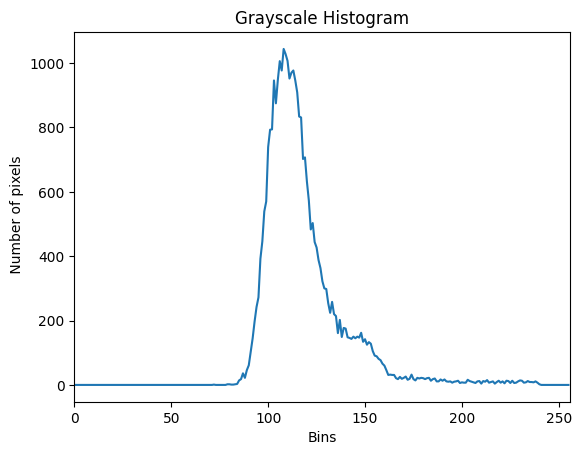

In [11]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


img=cv.imread("../image/apple.jpg")
blank=np.zeros(img.shape[:2],dtype="uint8")

# grayscale histogram
gray=cv.cvtColor(img,cv.COLOR_BGR2GRAY)
mask=cv.circle(blank,(img.shape[1]//2,img.shape[0]//2),100,255,-1)

gray_hist=cv.calcHist([gray],[0],mask,[256],[0,256])

plt.figure()
# plt.imshow(mask,cmap="gray")
# plt.show()
plt.title("Grayscale Histogram")
plt.xlabel("Bins")
plt.ylabel(" Number of pixels")
plt.plot(gray_hist)
plt.xlim([0,256])
plt.show()

**Histogram computed for particular mask**

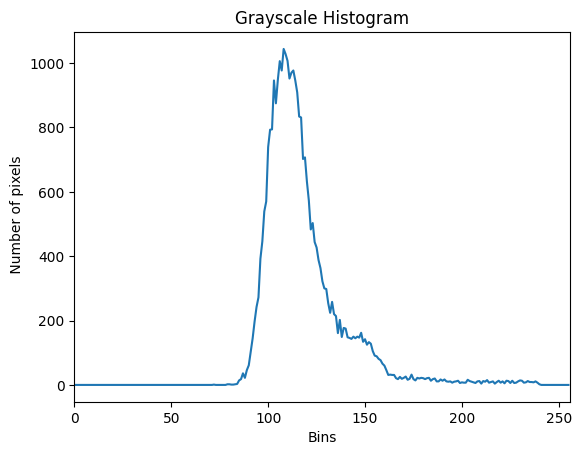

In [12]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


img=cv.imread("../image/apple.jpg")
blank=np.zeros(img.shape[:2],dtype="uint8")

# grayscale histogram
gray=cv.cvtColor(img,cv.COLOR_BGR2GRAY)
circle=cv.circle(blank,(img.shape[1]//2,img.shape[0]//2),100,255,-1)
mask=cv.bitwise_and(gray,gray,mask=circle)

gray_hist=cv.calcHist([gray],[0],mask,[256],[0,256])

plt.figure()
# plt.imshow(mask,cmap="gray")
# plt.show()
plt.title("Grayscale Histogram")
plt.xlabel("Bins")
plt.ylabel(" Number of pixels")
plt.plot(gray_hist)
plt.xlim([0,256])
plt.show()

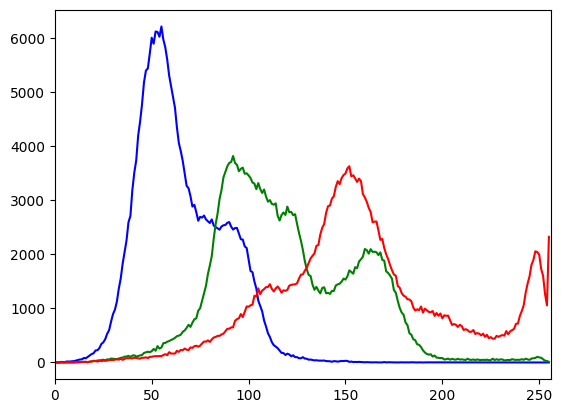

In [15]:
# colors histogram

colors = ("b","g","r")

for i, col in enumerate(colors):
    hist=cv.calcHist([img],[i],None,[256],[0,256])
    plt.plot(hist,color=col)
    plt.xlim([0,256])
plt.show()

```TEXT
Reading a Histogram at a Glance

Peak on the far left: The image is very dark or under-exposed (lots of shadows/black background).
Peak on the far right: The image is very bright or over-exposed (lots of highlights/white sky).
A bell curve right in the middle: The image is well-balanced with good contrast.